In [ ]:
import ipywidgets as widgets
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import numpy
import pandas as pd
import seaborn as sns
from scipy.stats import sem  # standard error of the mean
import matplotlib.cbook as cbook  # to format boxplots
import matplotlib.cm as cm  # to format plots

In [ ]:
all_data = pd.read_csv('/Volumes/rdss_krothenberg-1/Allie Orozco/April experiment/Collagen I - individual dishes Results.csv')
print(all_data.columns)

In [ ]:
all_data

,0,1,2,3,4
0,1,1,-1.0,95.222221,-37.614684
1,1,1,-0.5,87.170055,-37.614684
2,1,1,0.0,56.369781,-37.614684
3,1,1,0.5,68.851265,-37.614684
4,1,1,1.0,86.770588,-37.614684
...,...,...,...,...,...
1711,2,26,13.0,57.862981,-26.024882
1712,2,26,13.5,56.191291,-26.024882
1713,2,26,14.0,55.740127,-26.024882
1714,2,26,14.5,44.273367,-26.024882


In [ ]:
sns.set()
sns.set_style("white")
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = [8, 6]

n_groups = 2
my_palette = ["#455F50","#913F72","#E59010","#61BDD1"];
sns.set_palette(my_palette)

In [ ]:
thedata = all_data.groupby([0, 1], as_index=False, sort=False).first()

In [ ]:
dish1 = all_data.loc[all_data['Dish'] == 1]['Mean'].to_list()
dish2 = all_data.loc[all_data['Dish'] == 2]['Mean'].to_list()
dish3 = all_data.loc[all_data['Dish'] == 3]['Mean'].to_list()
dish4 = all_data.loc[all_data['Dish'] == 4]['Mean'].to_list()
dish5 = all_data.loc[all_data['Dish'] == 5]['Mean'].to_list()
input_data = [dish1, dish2, dish3, dish4]

In [ ]:
def boxplotMeanSD(input_data, ax):
    # one dimensional/flattened data
    props = dict(linewidth=2, color='k')
    colours = ["#455F50","#913F72","#E59010","#61BDD1"]

    for ii in range(len(input_data)):
        stats = {}
        data = input_data[ii]

        mean_data = numpy.nanmean(data)
        s_dev = numpy.nanstd(data)
        s_err = sem(data, nan_policy='omit')

        min_data = mean_data - s_dev
        max_data = mean_data + s_dev

        firstQ = mean_data - s_err
        thirdQ = mean_data + s_err

        stats = cbook.boxplot_stats(data, labels=str(ii))[0]
        stats['q1'] = firstQ
        stats['q3'] = thirdQ
        stats['mean'] = mean_data
        stats['iqr'] = 2*s_err
        stats['whishi'] = max_data
        stats['whislo'] = min_data
        stats['fliers'] = []
        stats['med'] = mean_data

        ax.bxp([stats], positions=[ii], widths=0.5, showcaps=None, boxprops=props, whiskerprops=props, medianprops=props)

    sns.stripplot(data=input_data, size=5.5, palette=colours[0:len(input_data)], alpha=0.75, edgecolor='k', ax=ax, linewidth=1.5)

    return

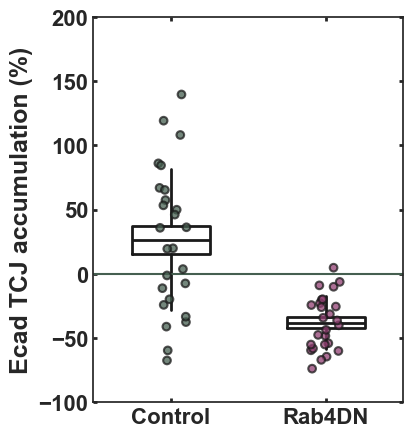

In [ ]:
fig, ax = plt.subplots()

boxplotMeanSD(input_data, ax)

# Update these labels to match your Dish IDs
ax.set_xticklabels(['Dish 1', 'Dish 2', 'Dish 3', 'Dish 4'])

ax.set_ylabel('Mean Intensity')
ax.set_title('Collagen I Analysis by Dish')

plt.show()

/var/folders/48/ggs_jz2j2y5dmn9p57tnrf18j1xz5_/T/ipykernel_53419/1333906575.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.lineplot(x=2, y=3, hue=0, data=all_data, errorbar='se', err_style='band', lw=3, palette=my_palette)


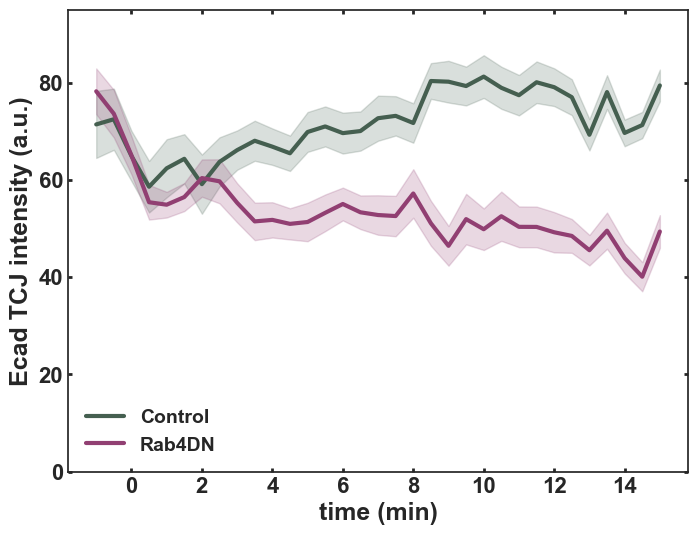

In [ ]:
ax = sns.lineplot(x=2, y=3, hue=0, data=all_data, errorbar='se', err_style='band', lw=3, palette=my_palette)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Control', 'Rab4DN'], frameon=False)

plt.tick_params(direction='in', length=3, width=2)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
plt.ylabel("Ecad TCJ intensity (a.u.)")
plt.xlabel("time (min)")

ax.set(ylim=(0,95))

plt.xticks(fontfamily='Arial', fontweight='bold')

plt.show()

fig = ax.get_figure()
fig.savefig('TCJ intensity vs time.svg')

In [ ]:
import scipy.stats as stats

stats.mannwhitneyu(control_list, exp_list) 

MannwhitneyuResult(statistic=np.float64(571.0), pvalue=np.float64(2.0902399884646447e-05))